#  Auto MPG — Linear Regression Pipeline

**Objective:** Predict a car's fuel efficiency (`mpg`) from engine and body specifications using a reproducible, end-to-end scikit-learn Pipeline.

| | |
|---|---|
| **Dataset** | UCI Auto MPG (398 rows × 9 columns) |
| **Task** | Supervised Regression |
| **Target** | `mpg` — miles per gallon |
| **Model** | Linear Regression (with Ridge & Lasso comparison) |
| **Author** | *(your name)* |
| **Date** | *(date)* |

---

### Table of Contents
1. [Imports & Configuration](#1)
2. [Data Loading & First Look](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Pipeline Construction](#5)
6. [Model Training & Evaluation](#6)
7. [Residual & Error Analysis](#7)
8. [Feature Importance](#8)
9. [Hyperparameter Tuning](#9)
10. [Final Summary](#10)


## 1. Imports & Configuration <a id='1'></a>

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data Handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Pipeline & Column Transformer ───────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# ── Scikit-learn: Model Selection ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 2. Data Loading & First Look <a id='2'></a>

In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("auto-mpg.csv")

print(f"Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n")
df.head()


Shape  : 398 rows × 9 columns
Memory : 73.4 KB



,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
# ── Data Types & Missing Values ───────────────────────────────────────────────
info = pd.DataFrame({
    "dtype"   : df.dtypes,
    "nulls"   : df.isnull().sum(),
    "null_%"  : (df.isnull().sum() / len(df) * 100).round(2),
    "unique"  : df.nunique(),
})
print(info.to_string())


                dtype  nulls  null_%  unique
mpg           float64      0     0.0     129
cylinders       int64      0     0.0       5
displacement  float64      0     0.0      82
horsepower     object      0     0.0      94
weight          int64      0     0.0     351
acceleration  float64      0     0.0      95
model year      int64      0     0.0      13
origin          int64      0     0.0       3
car name       object      0     0.0     305


In [4]:
# ── Statistical Summary ───────────────────────────────────────────────────────
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mpg,398.0,NaN,NaN,NaN,23.514573,7.815984,9.0,17.5,23.0,29.0,46.6
cylinders,398.0,NaN,NaN,NaN,5.454774,1.701004,3.0,4.0,4.0,8.0,8.0
displacement,398.0,NaN,NaN,NaN,193.425879,104.269838,68.0,104.25,148.5,262.0,455.0
horsepower,398,94,150,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,398.0,NaN,NaN,NaN,2970.424623,846.841774,1613.0,2223.75,2803.5,3608.0,5140.0
acceleration,398.0,NaN,NaN,NaN,15.56809,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,NaN,NaN,NaN,76.01005,3.697627,70.0,73.0,76.0,79.0,82.0
origin,398.0,NaN,NaN,NaN,1.572864,0.802055,1.0,1.0,1.0,2.0,3.0
car name,398,305,ford pinto,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

> **Key insight we are looking for:** Which features correlate most with `mpg`?


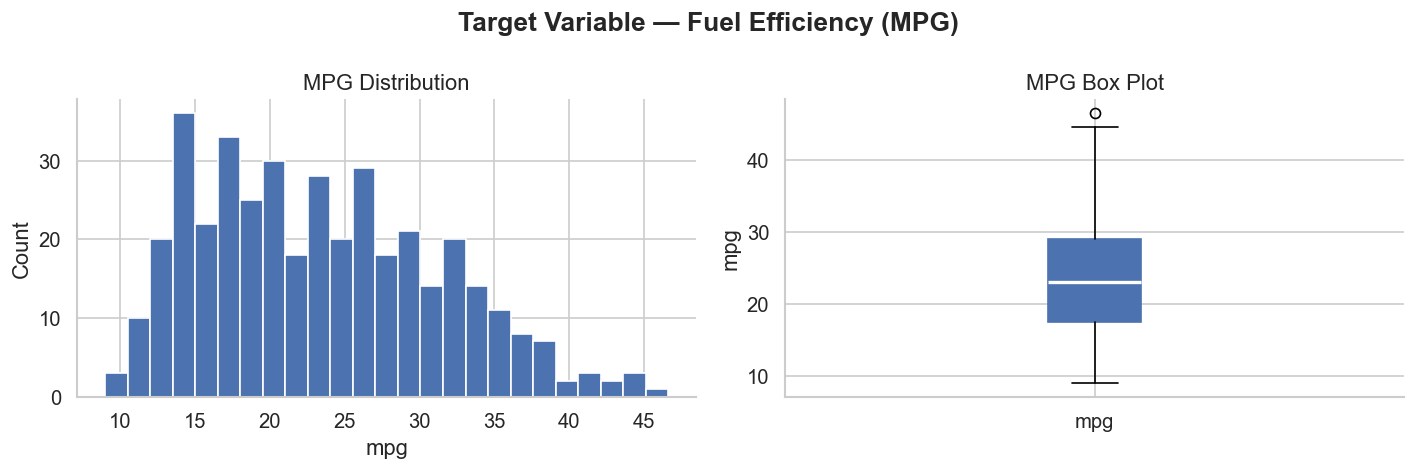

Skewness : 0.457
Kurtosis : -0.511


In [5]:
# ── Fix horsepower: '?' → NaN, then cast to float ────────────────────────────
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# ── Target Distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["mpg"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].set(title="MPG Distribution", xlabel="mpg", ylabel="Count")

axes[1].boxplot(df["mpg"], patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", color="#4C72B0"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set(title="MPG Box Plot", ylabel="mpg", xticklabels=["mpg"])

plt.suptitle("Target Variable — Fuel Efficiency (MPG)", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Skewness : {df['mpg'].skew():.3f}")
print(f"Kurtosis : {df['mpg'].kurt():.3f}")


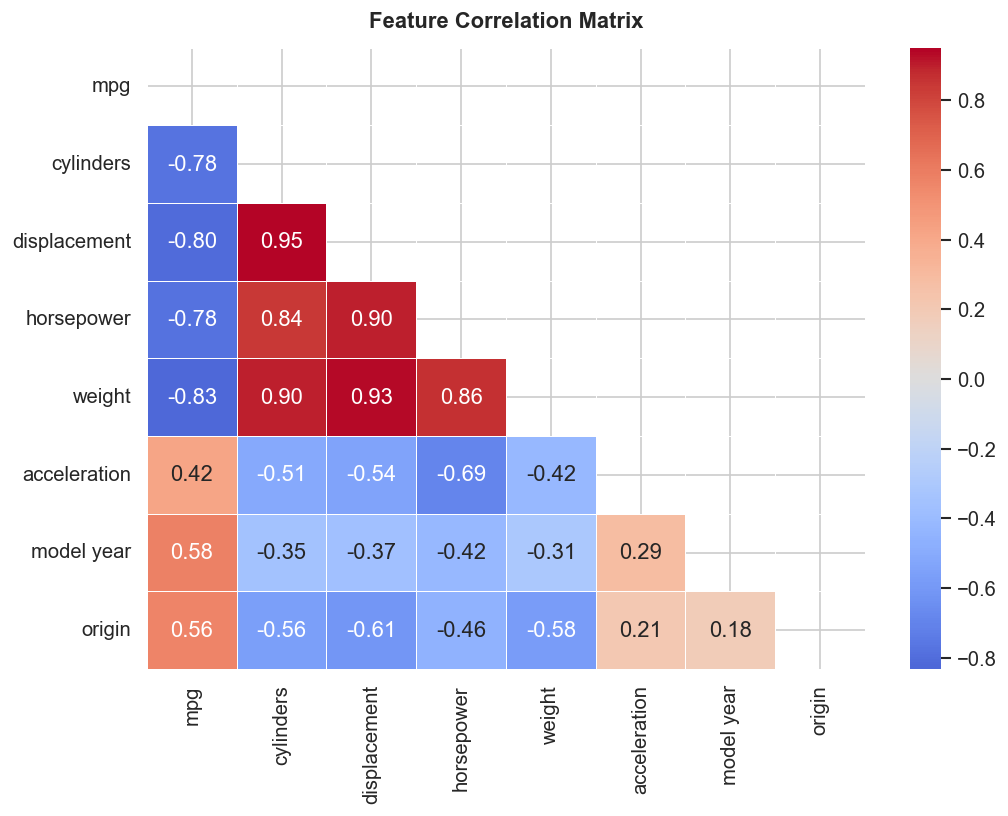

In [6]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


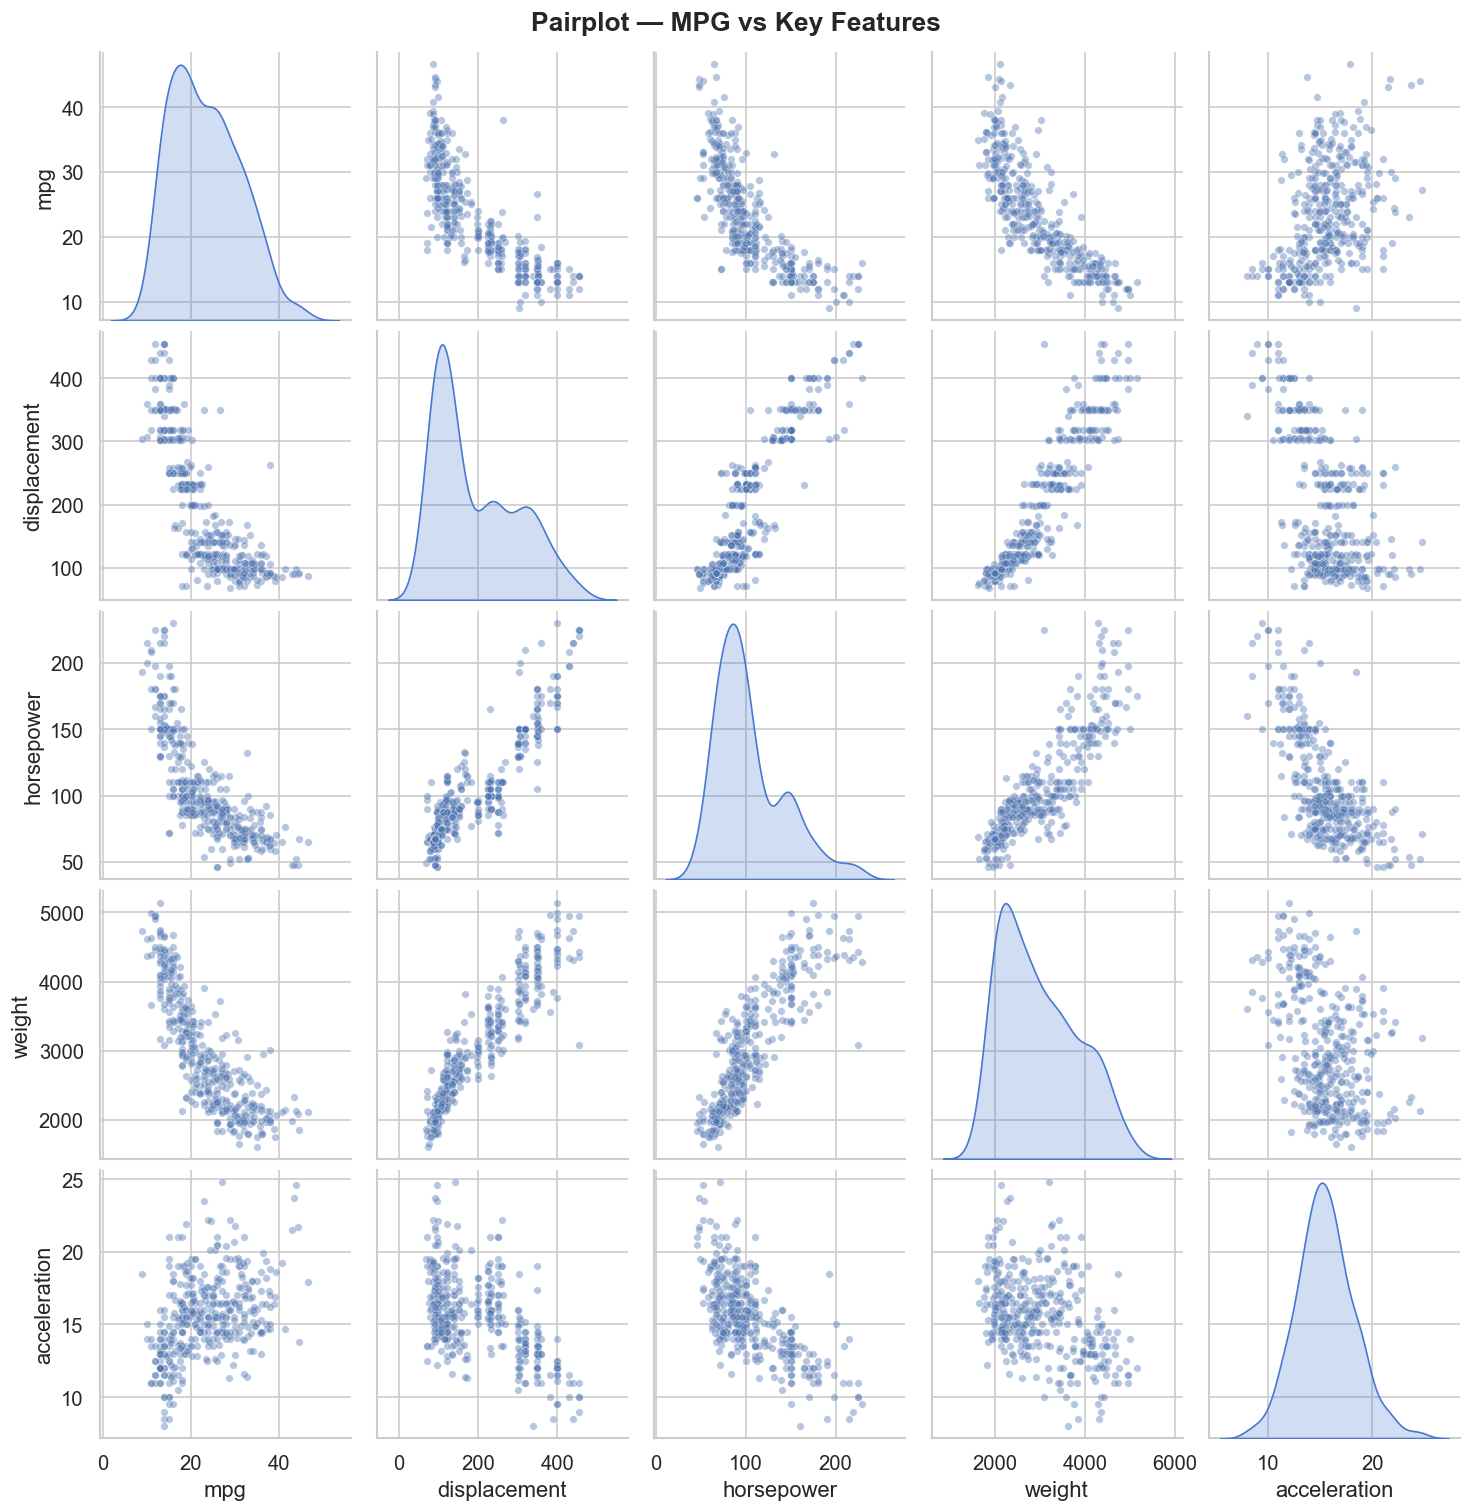

In [7]:
# ── Scatter Matrix (top correlated features) ──────────────────────────────────
top_features = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
sns.pairplot(df[top_features].dropna(), diag_kind="kde",
             plot_kws={"alpha": 0.4, "s": 20, "color": "#4C72B0"})
plt.suptitle("Pairplot — MPG vs Key Features", y=1.01, fontweight="bold")
plt.show()


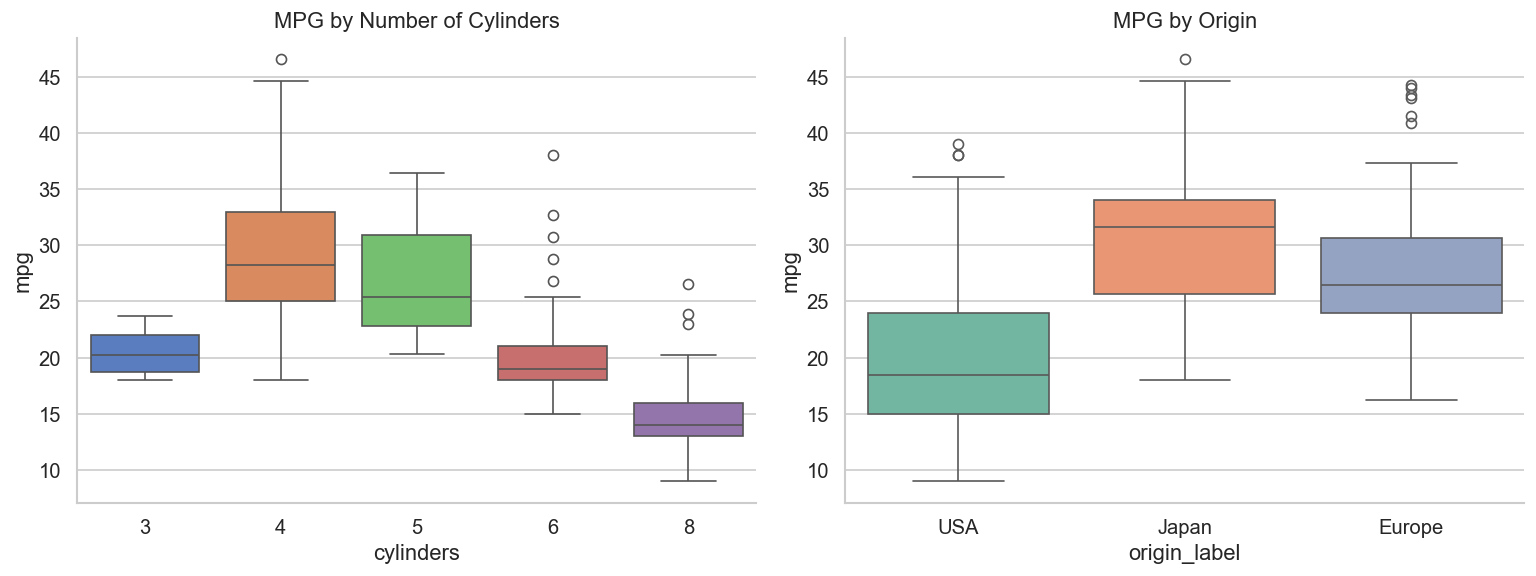

In [8]:
# ── MPG by Cylinders & Origin ─────────────────────────────────────────────────
origin_map = {1: "USA", 2: "Europe", 3: "Japan"}
df["origin_label"] = df["origin"].map(origin_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="cylinders", y="mpg", palette="muted", ax=axes[0])
axes[0].set_title("MPG by Number of Cylinders")

sns.boxplot(data=df, x="origin_label", y="mpg", palette="Set2", ax=axes[1])
axes[1].set_title("MPG by Origin")

plt.tight_layout()
plt.show()


## 4. Data Preprocessing <a id='4'></a>

### Strategy
| Step | Action |
|---|---|
| `horsepower` | Had 6 `'?'` entries → converted to `NaN`, imputed with **median** |
| `car name` | Dropped — high cardinality, no predictive signal for regression |
| Numeric features | Impute (median) → StandardScaler |
| Categorical feature (`origin`) | OneHotEncoder (drop first to avoid multicollinearity) |


In [9]:
# ── Feature / Target Split ────────────────────────────────────────────────────
TARGET = "mpg"
DROP_COLS = ["car name", "origin_label"]   # non-predictive

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

# ── Identify column types ─────────────────────────────────────────────────────
numeric_features     = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nDataset size — X: {X.shape}  |  y: {y.shape}")


Numeric features    : ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
Categorical features: []

Dataset size — X: (398, 7)  |  y: (398,)


In [10]:
# ── Train / Test Split (80/20, stratified on cylinder bins) ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")


Train : 318 samples
Test  : 80 samples


## 5. Pipeline Construction <a id='5'></a>

### What is a Pipeline & why use it?

```
Raw Data
   │
   ▼
ColumnTransformer ──┬── Numeric Branch  : Imputer (median) → StandardScaler
                    └── Categorical Branch: Imputer (most_frequent) → OneHotEncoder
   │
   ▼
LinearRegression
```

**Benefits:**
- **No data leakage** — the scaler fits *only* on train data; the same transform is applied to test data automatically.
- **Single `.fit()` / `.predict()` call** — cleaner code.
- **Production-ready** — the whole pipeline can be serialised with `joblib` and deployed directly.


In [11]:
# ── Numeric Transformer ───────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# ── Categorical Transformer ───────────────────────────────────────────────────
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")),
])

# ── ColumnTransformer (combines both branches) ────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ── Full Pipeline ─────────────────────────────────────────────────────────────
pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        LinearRegression()),
])

print("Pipeline architecture:")
print(pipeline_lr)


Pipeline architecture:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'acceleration', 'model year',
                                                   'origin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),

## 6. Model Training & Evaluation <a id='6'></a>

In [12]:
# ── Fit the Pipeline ──────────────────────────────────────────────────────────
pipeline_lr.fit(X_train, y_train)
print("✅ Pipeline fitted.")


✅ Pipeline fitted.


In [13]:
# ── Evaluation Helper ─────────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - X_train.shape[1] - 1)
    return {"Model": name, "MAE": round(mae,3), "RMSE": round(rmse,3),
            "R²": round(r2,4), "Adj-R²": round(adj_r2,4), "MAPE %": round(mape,2)}

# ── Cross-Validation (5-fold) ────────────────────────────────────────────────
cv_scores = cross_val_score(pipeline_lr, X_train, y_train,
                             cv=5, scoring="r2")
print(f"5-Fold CV R²  :  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual    :  {np.round(cv_scores, 4)}")


5-Fold CV R²  :  0.8005 ± 0.0240
Individual    :  [0.8377 0.7913 0.8166 0.788  0.7689]


In [14]:
# ── Train vs Test Metrics ─────────────────────────────────────────────────────
results = []
results.append(evaluate("Linear Regression (Train)",
                         y_train, pipeline_lr.predict(X_train)))
results.append(evaluate("Linear Regression (Test)",
                         y_test,  pipeline_lr.predict(X_test)))
metrics_df = pd.DataFrame(results)
metrics_df


,Model,MAE,RMSE,R²,Adj-R²,MAPE %
0,Linear Regression (Train),2.599,3.415,0.8140,0.8098,11.93
1,Linear Regression (Test),2.256,2.863,0.8475,0.8327,11.44


### Metric Glossary
| Metric | What it tells you |
|---|---|
| **MAE** | Average absolute error in *mpg* units. Intuitive. |
| **RMSE** | Same as MAE but penalises large errors more heavily. |
| **R²** | Proportion of variance explained (1.0 = perfect). |
| **Adj-R²** | R² adjusted for number of predictors — more honest. |
| **MAPE %** | Error as % of actual value — scale-independent. |


## 7. Residual & Error Analysis <a id='7'></a>

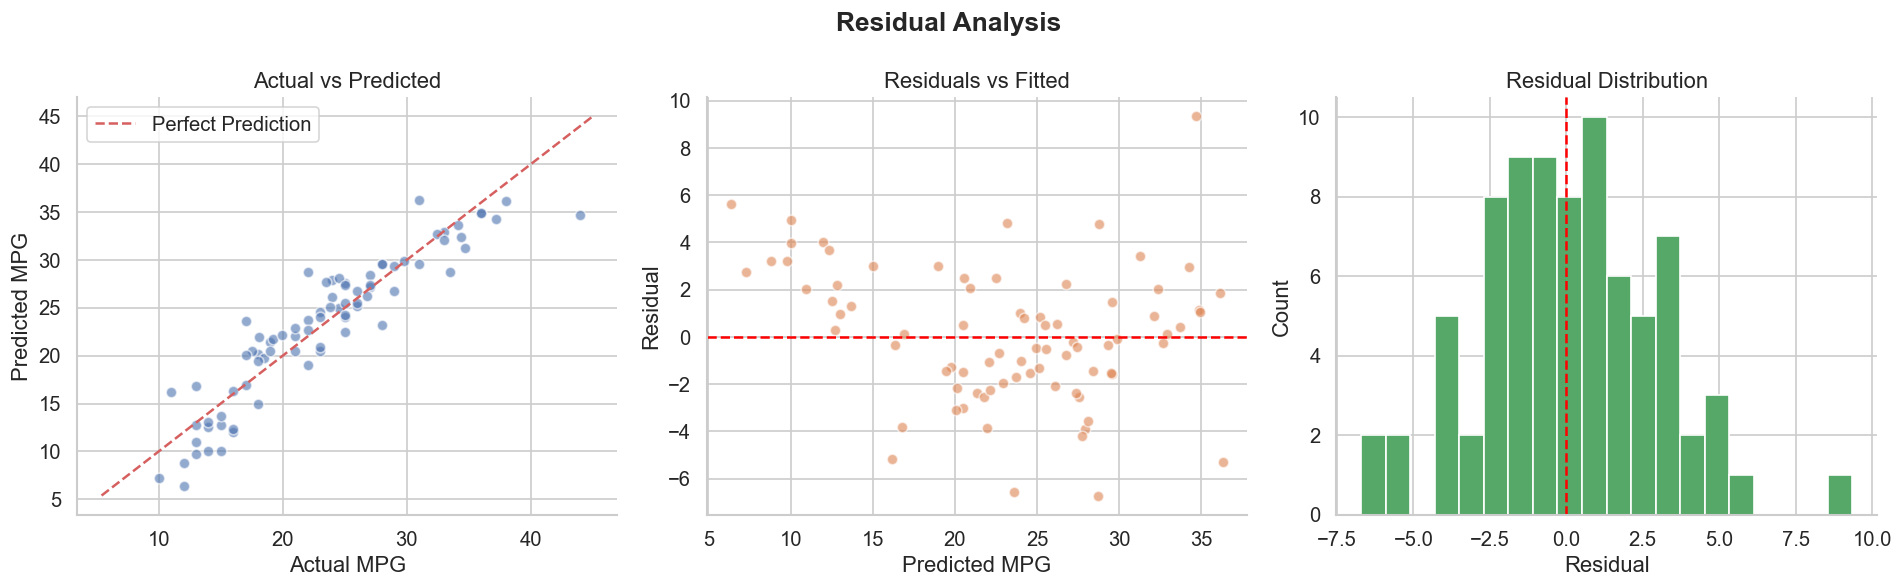

Residual mean  : 0.0862  (should be ≈ 0)
Residual std   : 2.8800


In [15]:
y_pred_test = pipeline_lr.predict(X_test)
residuals   = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color="#4C72B0", edgecolors="white", s=40)
lims = [min(y_test.min(), y_pred_test.min()) - 1,
        max(y_test.max(), y_pred_test.max()) + 1]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect Prediction")
axes[0].set(xlabel="Actual MPG", ylabel="Predicted MPG", title="Actual vs Predicted")
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.6, color="#DD8452", edgecolors="white", s=40)
axes[1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[1].set(xlabel="Predicted MPG", ylabel="Residual", title="Residuals vs Fitted")

# Residual Distribution
axes[2].hist(residuals, bins=20, color="#55A868", edgecolor="white")
axes[2].axvline(0, color="red", linestyle="--", lw=1.5)
axes[2].set(xlabel="Residual", ylabel="Count", title="Residual Distribution")

plt.suptitle("Residual Analysis", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Residual mean  : {residuals.mean():.4f}  (should be ≈ 0)")
print(f"Residual std   : {residuals.std():.4f}")


## 8. Feature Importance (Coefficients) <a id='8'></a>

Features: 7
Coefs   : 7


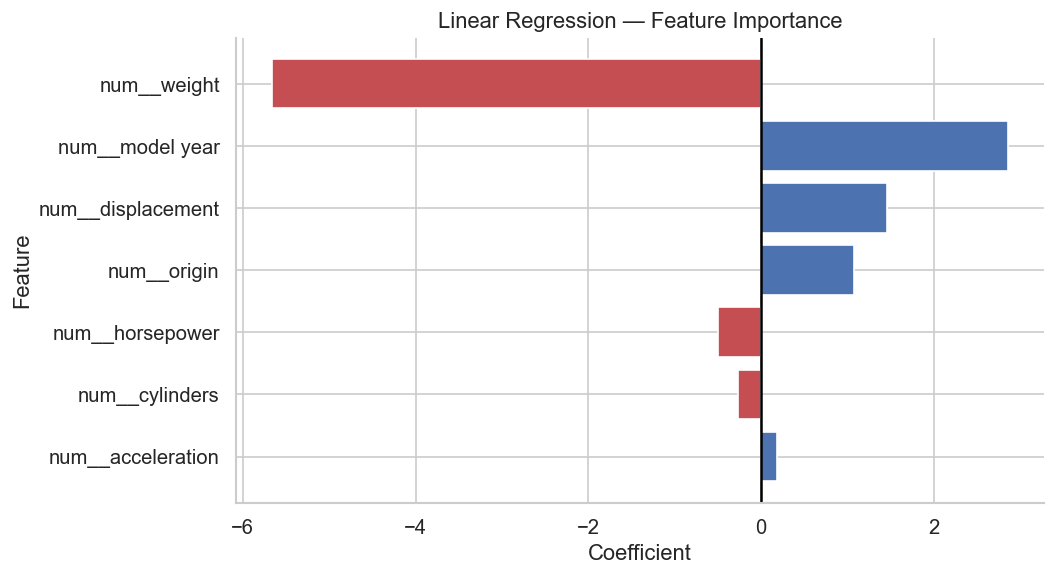

             Feature  Coefficient
0        num__weight    -5.659110
1    num__model year     2.859148
2  num__displacement     1.465106
3        num__origin     1.073207
4    num__horsepower    -0.494947
5     num__cylinders    -0.264273
6  num__acceleration     0.187582


In [16]:
# ── Feature Importance (Coefficients) ────────────────────────────────────────

fitted_pre = pipeline_lr.named_steps["preprocessor"]

feature_names = fitted_pre.get_feature_names_out()
coefs = pipeline_lr.named_steps["model"].coef_.ravel()

print("Features:", len(feature_names))
print("Coefs   :", len(coefs))

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
})

coef_df = (
    coef_df.iloc[coef_df["Coefficient"].abs().sort_values(ascending=False).index]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9,5))

colors = ["#4C72B0" if c > 0 else "#C44E52"
          for c in coef_df["Coefficient"]]

ax.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors
)

ax.axvline(0, color="black")
ax.invert_yaxis()

ax.set_title("Linear Regression — Feature Importance")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

print(coef_df)

In [17]:
print("numeric_features =", numeric_features)
print("categorical_features =", categorical_features)

print("\nColumns in X_train:")
print(X_train.columns.tolist())

print("\nTransformed feature names:")
print(pipeline_lr.named_steps["preprocessor"].get_feature_names_out())

numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
categorical_features = []

Columns in X_train:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']

Transformed feature names:
['num__cylinders' 'num__displacement' 'num__horsepower' 'num__weight'
 'num__acceleration' 'num__model year' 'num__origin']


## 9. Model Comparison & Hyperparameter Tuning <a id='9'></a>

We compare **OLS Linear Regression**, **Ridge** (L2 regularisation), and **Lasso** (L1 regularisation)
using `GridSearchCV` to find the best `alpha` for Ridge/Lasso.


In [ ]:
# ── Ridge Pipeline + GridSearch ──────────────────────────────────────────────
pipeline_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        Ridge()),
])
param_grid_ridge = {"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 200]}
gs_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5,
                         scoring="r2", n_jobs=-1)
gs_ridge.fit(X_train, y_train)

# ── Lasso Pipeline + GridSearch ───────────────────────────────────────────────
pipeline_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        Lasso(max_iter=10_000)),
])
param_grid_lasso = {"model__alpha": [0.001, 0.01, 0.1, 0.5, 1, 5]}
gs_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5,
                         scoring="r2", n_jobs=-1)
gs_lasso.fit(X_train, y_train)

print(f"Best Ridge alpha : {gs_ridge.best_params_['model__alpha']}")
print(f"Best Lasso alpha : {gs_lasso.best_params_['model__alpha']}")


Best Ridge alpha : 1
Best Lasso alpha : 0.1


In [ ]:
# ── Compare All Three Models ──────────────────────────────────────────────────
all_results = [
    evaluate("Linear Regression", y_test, pipeline_lr.predict(X_test)),
    evaluate("Ridge (tuned)",      y_test, gs_ridge.best_estimator_.predict(X_test)),
    evaluate("Lasso (tuned)",      y_test, gs_lasso.best_estimator_.predict(X_test)),
]
compare_df = pd.DataFrame(all_results)
compare_df


,Model,MAE,RMSE,R²,Adj-R²,MAPE %
0,Linear Regression,2.256,2.863,0.8475,0.8327,11.44
1,Ridge (tuned),2.252,2.865,0.8473,0.8325,11.39
2,Lasso (tuned),2.249,2.896,0.8440,0.8288,11.22


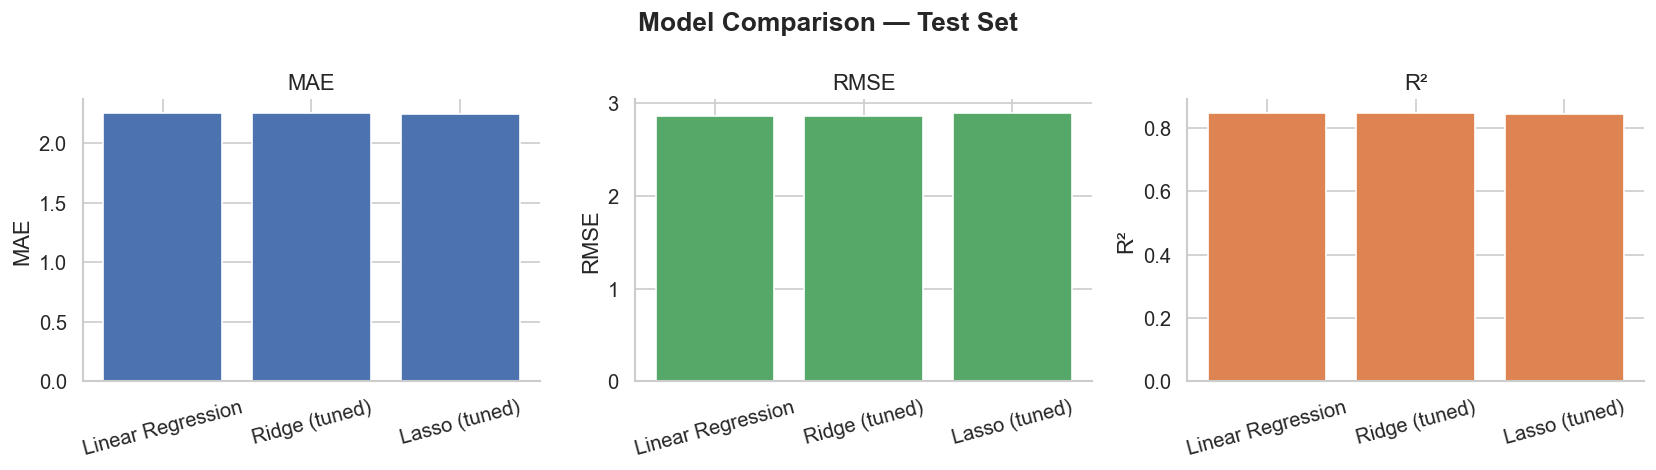

In [ ]:
# ── Visual Comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = ["MAE", "RMSE", "R²"]
colors = ["#4C72B0", "#55A868", "#DD8452"]

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    ax.bar(compare_df["Model"], compare_df[metric], color=color, edgecolor="white")
    ax.set(title=metric, ylabel=metric)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Model Comparison — Test Set", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Final Summary <a id='10'></a>

### Results at a Glance


In [ ]:
best_model = gs_ridge.best_estimator_
y_final    = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_final)
rmse = np.sqrt(mean_squared_error(y_test, y_final))
r2   = r2_score(y_test, y_final)

print("=" * 45)
print("       FINAL MODEL — Ridge Regression")
print("=" * 45)
print(f"  MAE   : {mae:.3f} mpg")
print(f"  RMSE  : {rmse:.3f} mpg")
print(f"  R²    : {r2:.4f}")
print("=" * 45)
print("\nInterpretation:")
print(f"  • The model explains {r2*100:.1f}% of variance in MPG.")
print(f"  • On average, predictions are off by ±{mae:.2f} mpg.")


       FINAL MODEL — Ridge Regression
  MAE   : 2.252 mpg
  RMSE  : 2.865 mpg
  R²    : 0.8473

Interpretation:
  • The model explains 84.7% of variance in MPG.
  • On average, predictions are off by ±2.25 mpg.


### Key Takeaways

1. **Weight, displacement, and horsepower** are the strongest negative predictors of MPG — heavier, more powerful cars consume more fuel.
2. **Model year** has a positive coefficient — newer cars (late 70s–early 80s) tend to be more efficient.
3. **Ridge regularisation** gave marginally better generalisation than plain OLS, suggesting mild multicollinearity between features (displacement/weight/horsepower are correlated).
4. **Pipeline architecture** prevents data leakage and makes the model deployment-ready.

### Possible Extensions
- Feature engineering: `power_to_weight` ratio, log-transform of `displacement`
- Try **Polynomial Features** + Ridge to capture non-linear relationships
- Explore **Gradient Boosting** (XGBoost / LightGBM) for comparison
- Deploy as a **FastAPI** endpoint with `joblib` serialisation
